In [60]:
#import files 
import pandas as pd
import os
os.listdir("data")

['2021 Student summary tables.xlsx',
 'Copy of Research block grants time series 2021-2026.xlsx',
 'Copy of 2024_Student_Summary_Tables.xlsx',
 'Copy of Copy of 2025 Staff A2 Student Staff Ratios.xlsx',
 'RSP_cohort_trend.xlsx',
 'Copy of Copy of 2024_Student_Summary_Tables.xlsx',
 'Copy of 2025 Staff A2 Student Staff Ratios.xlsx',
 '2022 Student summary tables_revised.xlsx']

In [61]:
rbg_file = "data/Copy of Research block grants time series 2021-2026.xlsx"

rbg_excel = pd.ExcelFile(rbg_file)

rbg_excel.sheet_names

['Contents', 'Table 1', 'Table 2', 'Table 3', 'Notes']

In [62]:
#read table 2 from file Research block grants time series 2021-2026 
rbg = pd.read_excel(
    rbg_file,
    sheet_name="Table 2", 
    header =2
)

rbg.head(20)

,HEP Code,HEP Name,Year,State,Cohort,Program,Amount
0,6102,Adelaide University,2026,SA,Go8,RSP,64130915
1,6102,Adelaide University,2026,SA,Go8,RTP,66199119
2,3006,Australian Catholic University,2026,OTHER,non-aligned,RSP,2614352
3,3006,Australian Catholic University,2026,OTHER,non-aligned,RTP,3446654
4,2252,Avondale University,2026,NSW,non-aligned,RSP,150478
5,2252,Avondale University,2026,NSW,non-aligned,RTP,256246
6,2246,Batchelor Institute of Indigenous Tertiary Edu...,2026,NT,non-aligned,RSP,689789
7,2246,Batchelor Institute of Indigenous Tertiary Edu...,2026,NT,non-aligned,RTP,443100
8,3003,Bond University,2026,QLD,non-aligned,RSP,1139827
9,3003,Bond University,2026,QLD,non-aligned,RTP,2298883


In [63]:
#show column names
rbg.columns.tolist()

['HEP Code', 'HEP Name', 'Year', 'State', 'Cohort', 'Program', 'Amount']

In [64]:
rbg_2026 = rbg[rbg["Year"] == 2026]

rsp_2026 = rbg_2026[rbg_2026["Program"] == "RSP"]

rsp_2026 = rsp_2026.sort_values("Amount", ascending=False)

rsp_2026.head(10)

,HEP Code,HEP Name,Year,State,Cohort,Program,Amount
48,3036,The University of Melbourne,2026,VIC,Go8,RSP,123798137
34,3035,Monash University,2026,VIC,Go8,RSP,122318192
66,3013,University of New South Wales,2026,NSW,Go8,RSP,110517912
54,3040,The University of Sydney,2026,NSW,Go8,RSP,103070321
52,3019,The University of Queensland,2026,QLD,Go8,RSP,98793200
46,3033,The Australian National University,2026,ACT,Go8,RSP,72597461
0,6102,Adelaide University,2026,SA,Go8,RSP,64130915
56,1055,The University of Western Australia,2026,WA,Go8,RSP,45734581
18,3030,Deakin University,2026,VIC,ATN,RSP,28555035
72,3045,University of Tasmania,2026,TAS,non-aligned,RSP,25338770


In [65]:
#isolate 2026 RSP funding
rsp = rbg[rbg["Program"] == "RSP"].copy()

cohort_funding = (
    rsp
    .groupby(["Year", "Cohort"], as_index=False)["Amount"]
    .sum()
)

cohort_funding["Amount_millions"] = (
    cohort_funding["Amount"] / 1_000_000
)

#cohort_funding

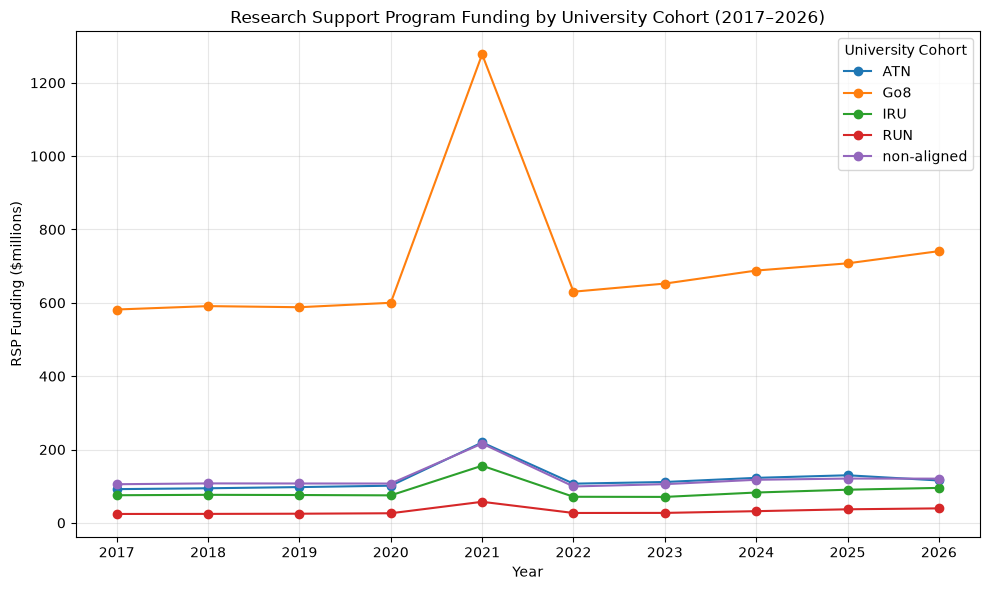

In [66]:
#GRAPH1
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

for cohort in cohort_funding["Cohort"].unique():
    data = cohort_funding[cohort_funding["Cohort"] == cohort]
    plt.plot(
        data["Year"],
        data["Amount_millions"],
        marker="o",
        label=cohort
    )

plt.xlabel("Year")
plt.ylabel("RSP Funding ($millions)")
plt.title("Research Support Program Funding by University Cohort (2017–2026)")
plt.legend(title="University Cohort")
plt.grid(alpha=0.3)

plt.xticks(range(2017, 2027))

plt.tight_layout()

plt.savefig("RSP_cohort_trend.png", dpi=300, bbox_inches="tight")

plt.show()

In [67]:
# Calculate total RSP funding for each university across 2017–2026
rsp_total = (
    rsp
    .groupby("HEP Name", as_index=False)["Amount"]
    .sum()
    .sort_values("Amount", ascending=False)
)

# Select the 10 universities with the highest cumulative RSP funding
top_12_unis = rsp_total.head(12)["HEP Name"].tolist()

top_12_unis

['The University of Melbourne',
 'Monash University',
 'University of New South Wales',
 'The University of Sydney',
 'The University of Queensland',
 'The Australian National University',
 'The University of Western Australia',
 'The University of Adelaide',
 'University of Newcastle',
 'University of Tasmania',
 'Curtin University',
 'Queensland University of Technology']

In [68]:
# Keep the original yearly RSP amounts for the selected universities
top_12_yearly = rsp[
    rsp["HEP Name"].isin(top_12_unis)
].copy()

# Convert funding to millions for easier interpretation
top_12_yearly["Amount_millions"] = (
    top_12_yearly["Amount"] / 1_000_000
)

# Sort by year and funding
top_12_yearly = top_12_yearly.sort_values(
    ["Year", "Amount"],
    ascending=[True, False]
)

top_12_yearly[["Year", "HEP Name", "Amount_millions"]]

,Year,HEP Name,Amount_millions
806,2017,The University of Melbourne,95.494543
810,2017,The University of Queensland,89.973213
812,2017,The University of Sydney,87.161024
790,2017,Monash University,81.367573
824,2017,University of New South Wales,78.445698
...,...,...,...
56,2026,The University of Western Australia,45.734581
72,2026,University of Tasmania,25.338770
16,2026,Curtin University,25.109253
68,2026,University of Newcastle,25.084794


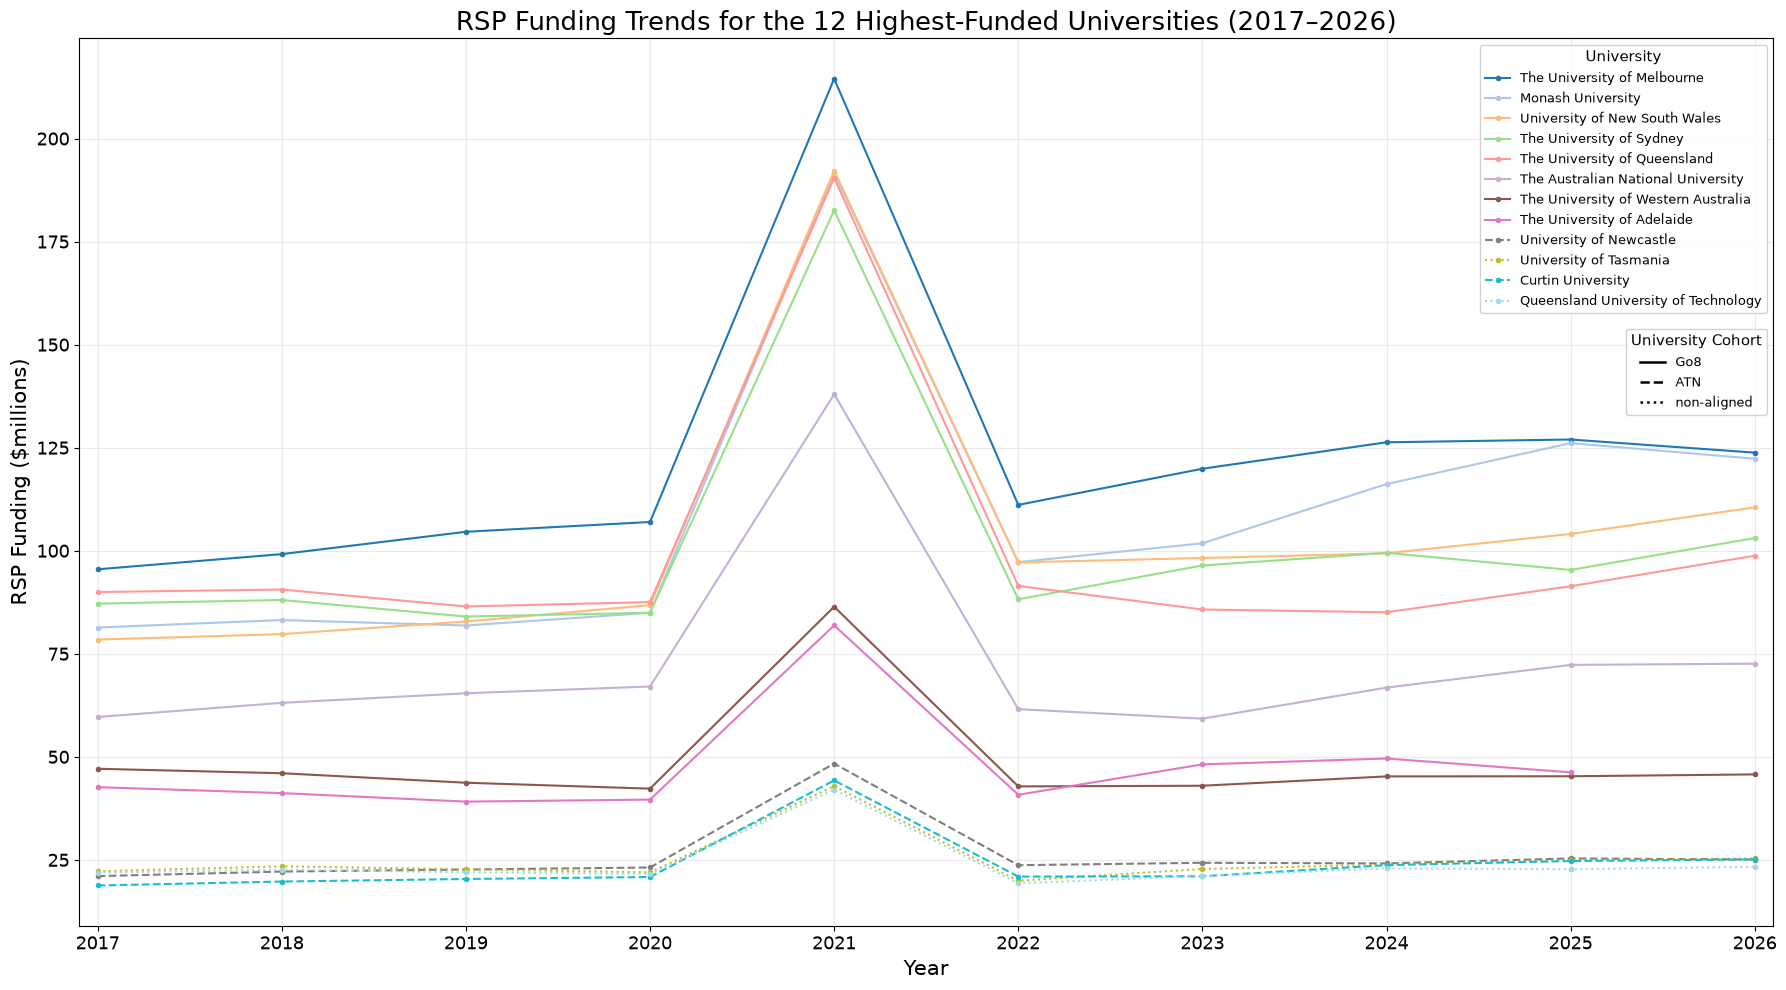

In [69]:
#GRAPH2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

plt.figure(figsize=(18, 10))

# 12 distinct colours for the universities
colours = plt.cm.tab20(np.linspace(0, 1, len(top_12_unis)))

# Line style based on university cohort
cohort_styles = {
    "Go8": "-",
    "ATN": "--",
    "non-aligned": ":"
}

for uni, colour in zip(top_12_unis, colours):

    data = top_12_yearly[
        top_12_yearly["HEP Name"] == uni
    ].sort_values("Year")

    # Get cohort for this university
    cohort = data["Cohort"].iloc[0]

    plt.plot(
        data["Year"],
        data["Amount_millions"],
        marker="o",
        linewidth=1.5,
        markersize=3,
        label=uni,
        color=colour,
        linestyle=cohort_styles.get(cohort, "-")
    )

plt.xlabel("Year", fontsize=15)
plt.ylabel("RSP Funding ($millions)", fontsize=15)

plt.title(
    "RSP Funding Trends for the 12 Highest-Funded Universities (2017–2026)",
    fontsize=19
)

plt.xticks(range(2017, 2027), fontsize=13)
plt.yticks(fontsize=13)

# white space
plt.xlim(2016.9, 2026.1)


university_legend = plt.legend(
    loc="upper right",
    fontsize=9,
    title="University",
    title_fontsize=11,
    frameon=True,
    framealpha=0.9
)

#  university legend on graph
plt.gca().add_artist(university_legend)



cohort_handles = [
    Line2D(
        [0], [0],
        color="black",
        linewidth=1.8,
        linestyle=style,
        label=cohort
    )
    for cohort, style in cohort_styles.items()
]

plt.legend(
    handles=cohort_handles,
    loc="upper right",
    bbox_to_anchor=(1, 0.68),
    fontsize=9,
    title="University Cohort",
    title_fontsize=11,
    frameon=True,
    framealpha=0.9
)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "RSP_top_12_university_trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [70]:
#read staff ratios document
import pandas as pd

staff_file = "data/Copy of 2025 Staff A2 Student Staff Ratios.xlsx"

staff = pd.read_excel(
    staff_file,
    sheet_name="A2.01",
    header=None
)

print(staff.shape)

(62, 28)


In [71]:
# rebuild the clean A2.01 dataset correctly from staff ratios document

staff_clean = staff.iloc[
    6:,
    [2, 3] + list(range(5, 15)) + list(range(16, 26))
].copy()

staff_clean.columns = [
    "Institution_Code",
    "Institution",
    "Academic_2015",
    "Academic_2016",
    "Academic_2017",
    "Academic_2018",
    "Academic_2019",
    "Academic_2020",
    "Academic_2021",
    "Academic_2022",
    "Academic_2023",
    "Academic_2024",
    "Professional_2015",
    "Professional_2016",
    "Professional_2017",
    "Professional_2018",
    "Professional_2019",
    "Professional_2020",
    "Professional_2021",
    "Professional_2022",
    "Professional_2023",
    "Professional_2024"
]

# Remove non-university rows
staff_clean = staff_clean[
    staff_clean["Institution_Code"].notna()
].copy()

staff_clean = staff_clean[
    staff_clean["Institution"] != "Grand total"
].copy()

# Convert ratios to numbers
ratio_columns = [
    col for col in staff_clean.columns
    if col.startswith("Academic_") or col.startswith("Professional_")
]

staff_clean[ratio_columns] = staff_clean[ratio_columns].apply(
    pd.to_numeric,
    errors="coerce"
)
staff_clean["Institution"] = staff_clean["Institution"].replace(
    "The University of Newcastle",
    "University of Newcastle"
)

# Reset index
staff_clean = staff_clean.reset_index(drop=True)


# Check the result
staff_clean[
    ["Institution", "Academic_2024", "Professional_2024"]
].head(15)

,Institution,Academic_2024,Professional_2024
0,Avondale University,12.416093,6.683517
1,Charles Sturt University,20.127011,13.025837
2,Macquarie University,28.145276,16.031239
3,Southern Cross University,27.890564,15.373127
4,The University of New England,20.889955,11.921315
5,University of Newcastle,26.047089,12.648708
6,The University of Sydney,22.783460,9.838301
7,University of New South Wales,23.548808,12.100916
8,University of Technology Sydney,26.175485,16.053030
9,University of Wollongong,21.766499,12.990012


In [72]:
#read staff summary tables beginning with 2024

import pandas as pd

student_file = "data/Copy of 2024_Student_Summary_Tables.xlsx"

student_excel = pd.ExcelFile(student_file)

student_excel.sheet_names

# Load Student Summary Table 4 (relevant slide from excel document)

student_2024 = pd.read_excel(
    student_file,
    sheet_name="4",
    header=None
)

student_2024.head()

,0,1,2,3,4,5,6,7,8,9,10
0,< Back to Contents >,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Table 4: Summary of Student Enrolments by Stat...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,,,Commencing Students,NaN,NaN,All Students,NaN,NaN,NaN,NaN,NaN
3,State,Institution,2023,2024,% change from 2023,2023,2024.0,% change from 2023,NaN,NaN,NaN
4,New South Wales,Charles Sturt University,13952,13906,-0.003297,34805,35003.0,0.005689,NaN,NaN,NaN


In [73]:
# clean Student Summary Table 4 for 2024

student_clean = student_2024.iloc[4:, [0, 1, 2, 3, 4, 5, 6, 7]].copy()

student_clean.columns = [
    "State",
    "Institution",
    "Commencing_Students_2023",
    "Commencing_Students_2024",
    "Commencing_Students_Pct_Change",
    "All_Students_2023",
    "All_Students_2024",
    "All_Students_Pct_Change"
]

# Remove rows without an institution
student_clean = student_clean[
    student_clean["Institution"].notna()
].copy()

# Remove state totals and overall total
student_clean = student_clean[
    ~student_clean["Institution"].astype(str).str.startswith("Total")
].copy()

# Convert numeric columns to numbers
numeric_columns = [
    "Commencing_Students_2023",
    "Commencing_Students_2024",
    "All_Students_2023",
    "All_Students_2024"
]

student_clean[numeric_columns] = student_clean[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

# Convert percentage columns from strings such as "17.1%" to numbers
student_clean["Commencing_Students_Pct_Change"] = (
    student_clean["Commencing_Students_Pct_Change"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

student_clean["All_Students_Pct_Change"] = (
    student_clean["All_Students_Pct_Change"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

student_clean["Commencing_Students_Pct_Change"] = pd.to_numeric(
    student_clean["Commencing_Students_Pct_Change"],
    errors="coerce"
)

student_clean["All_Students_Pct_Change"] = pd.to_numeric(
    student_clean["All_Students_Pct_Change"],
    errors="coerce"
)

# Clean university names
student_clean["Institution"] = (
    student_clean["Institution"]
    .astype(str)
    .str.replace(r"\(1\.\d+\)", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Make university names consistent with your other datasets
student_clean["Institution"] = student_clean["Institution"].replace({
    "The University of Newcastle": "University of Newcastle"
})

# Reset index
student_clean = student_clean.reset_index(drop=True)

# Check the cleaned table
student_clean.head()

,State,Institution,Commencing_Students_2023,Commencing_Students_2024,Commencing_Students_Pct_Change,All_Students_2023,All_Students_2024,All_Students_Pct_Change
0,New South Wales,Charles Sturt University,13952,13906.0,-0.003297,34805,35003.0,0.005689
1,New South Wales,Macquarie University,16891,16396.0,-0.029306,44240,44849.0,0.013766
2,New South Wales,Southern Cross University,7808,8587.0,0.099769,17296,18348.0,0.060823
3,New South Wales,The University of New England,7326,6846.0,-0.065520,20172,19355.0,-0.040502
4,New South Wales,University of Newcastle,13856,15121.0,0.091296,34071,34808.0,0.021631


In [74]:
# Read 2022 Student Summary Tables and specifically load table 4 (relevant slide)

student_2022_file = "data/2022 Student summary tables_revised.xlsx"

student_2022_excel = pd.ExcelFile(student_2022_file)

student_2022_excel.sheet_names

['Contents', '1 ', '2', '3', '4', '5 ', '6', '7', '8']

In [75]:
# Load Table 4
student_2022 = pd.read_excel(
    student_2022_file,
    sheet_name="4",
    header=None
)

# check the rows
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 60)

student_2022.head()

,0,1,2,3,4,5,6,7,8,9,10
0,<Back to contents>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Table 4: Summary of student numbers - List of ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Public Universities(a),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Institution,Commencing Students,NaN,NaN,NaN,NaN,All Students,NaN,NaN,NaN
4,NaN,NaN,2021,2022,NaN,% change from 2021,NaN,2021,2022,NaN,% change from 2021


In [76]:
# Clean 2022 Table 4
# Exclude "% of total"
# Keep "% change from 2021"

student_2022_clean = student_2022.iloc[6:56].copy()

# Select the correct columns
student_2022_clean = student_2022_clean[
    [
        0,   # State
        1,   # Institution
        2,   # Commencing Students 2021
        3,   # Commencing Students 2022
        5,   # Commencing Students % change from 2021
        7,   # All Students 2021
        8,   # All Students 2022
        10   # All Students % change from 2021
    ]
].copy()

student_2022_clean.columns = [
    "State",
    "Institution",
    "Commencing_Students_2021",
    "Commencing_Students_2022",
    "Commencing_Students_Pct_Change",
    "All_Students_2021",
    "All_Students_2022",
    "All_Students_Pct_Change"
]

# Fill state names down
student_2022_clean["State"] = (
    student_2022_clean["State"].ffill()
)

# Remove rows without an institution
student_2022_clean = student_2022_clean[
    student_2022_clean["Institution"].notna()
].copy()

# Remove state/overall total rows
student_2022_clean = student_2022_clean[
    ~student_2022_clean["Institution"]
    .astype(str)
    .str.contains("Total", case=False, na=False)
].copy()

# Convert student numbers to numeric
numeric_columns = [
    "Commencing_Students_2021",
    "Commencing_Students_2022",
    "All_Students_2021",
    "All_Students_2022"
]

student_2022_clean[numeric_columns] = (
    student_2022_clean[numeric_columns]
    .apply(pd.to_numeric, errors="coerce")
)

# Convert percentage-change columns to decimals
percentage_columns = [
    "Commencing_Students_Pct_Change",
    "All_Students_Pct_Change"
]

for column in percentage_columns:
    student_2022_clean[column] = pd.to_numeric(
        student_2022_clean[column],
        errors="coerce"
    )

# Clean institution names
student_2022_clean["Institution"] = (
    student_2022_clean["Institution"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Make university names consistent with other datasets
student_2022_clean["Institution"] = student_2022_clean["Institution"].replace({
    "The University of Newcastle": "University of Newcastle"
})

# Reset index
student_2022_clean = student_2022_clean.reset_index(drop=True)

# View cleaned data
student_2022_clean.head(15)

,State,Institution,Commencing_Students_2021,Commencing_Students_2022,Commencing_Students_Pct_Change,All_Students_2021,All_Students_2022,All_Students_Pct_Change
0,New South Wales,Charles Sturt University,18001,14683.0,-0.184323,40385,36659,-0.092262
1,New South Wales,Macquarie University,16058,15446.0,-0.038112,44895,43944,-0.021183
2,New South Wales,Southern Cross University,7704,7702.0,-0.000260,18676,17183,-0.079942
3,New South Wales,The University of New England,8238,7139.0,-0.133406,23691,21309,-0.100545
4,New South Wales,University of Newcastle,15288,13717.0,-0.102760,36829,35155,-0.045453
5,New South Wales,The University of Sydney,27863,26541.0,-0.047446,77431,77109,-0.004159
6,New South Wales,University of New South Wales,24983,25329.0,0.013849,65622,66538,0.013959
7,New South Wales,University of Technology Sydney,14665,15661.0,0.067917,43251,44727,0.034126
8,New South Wales,University of Wollongong,11323,11930.0,0.053608,32000,31042,-0.029937
9,New South Wales,Western Sydney University,16122,16822.0,0.043419,48614,46828,-0.036738


In [77]:
#Load the 2021 Student Summary Tables

student_2021_file = "data/2021 Student summary tables.xlsx"

student_2021_excel = pd.ExcelFile(student_2021_file)

student_2021_excel.sheet_names

['Contents', '1 ', '2', '3', '4', '5 ', '6', '7', '8']

In [78]:
# Load Table 4 from the 2021 Student Summary Tables

student_2021 = pd.read_excel(
    student_2021_file,
    sheet_name="4",
    header=None
)

# Show the first 60 rows and all columns to check
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 60)

student_2021.head(60)

,0,1,2,3,4,5,6,7,8,9,10
0,<Back to contents>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,<Back to contents>,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Table 4: Summary of student numbers - List of ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Public Universities(a),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Institution,Commencing Students,NaN,NaN,NaN,NaN,All Students,NaN,NaN,NaN
5,NaN,NaN,2020,2021,NaN,% change from 2020,NaN,2020,2021,NaN,% change from 2020
6,State,NaN,No.,No.,% of total,NaN,NaN,No.,No.,% of total,NaN
7,New South Wales,Charles Sturt University,18772,18001,0.112334,-0.041072,NaN,43332,40385,0.093615,-0.06801
8,NaN,Macquarie University,17413,16058,0.100209,-0.077815,NaN,44829,44895,0.10407,0.001472
9,NaN,Southern Cross University,9040,7704,0.048076,-0.147788,NaN,19898,18676,0.043292,-0.061413


In [79]:
# Clean 2021 Table 4
# Exclude "% of total"
# Keep "% change from 2020"

student_2021_clean = student_2021.iloc[6:].copy()

# Select the correct columns
student_2021_clean = student_2021_clean[
    [
        0,   # State
        1,   # Institution
        2,   # Commencing Students 2020
        3,   # Commencing Students 2021
        5,   # Commencing Students % change from 2020
        7,   # All Students 2020
        8,   # All Students 2021
        10   # All Students % change from 2020
    ]
].copy()

student_2021_clean.columns = [
    "State",
    "Institution",
    "Commencing_Students_2020",
    "Commencing_Students_2021",
    "Commencing_Students_Pct_Change",
    "All_Students_2020",
    "All_Students_2021",
    "All_Students_Pct_Change"
]

# Fill state names down
student_2021_clean["State"] = (
    student_2021_clean["State"].ffill()
)

# Remove rows without an institution
student_2021_clean = student_2021_clean[
    student_2021_clean["Institution"].notna()
].copy()

# Remove state/overall total rows
student_2021_clean = student_2021_clean[
    ~student_2021_clean["Institution"]
    .astype(str)
    .str.contains("Total", case=False, na=False)
].copy()

# Convert student numbers to numeric
numeric_columns = [
    "Commencing_Students_2020",
    "Commencing_Students_2021",
    "All_Students_2020",
    "All_Students_2021"
]

student_2021_clean[numeric_columns] = (
    student_2021_clean[numeric_columns]
    .apply(pd.to_numeric, errors="coerce")
)

# Convert percentage-change columns to numeric
# The Excel data is already stored as decimals,
# e.g. -0.041072 = -4.1%
percentage_columns = [
    "Commencing_Students_Pct_Change",
    "All_Students_Pct_Change"
]

for column in percentage_columns:
    student_2021_clean[column] = pd.to_numeric(
        student_2021_clean[column],
        errors="coerce"
    )

# Clean institution names
student_2021_clean["Institution"] = (
    student_2021_clean["Institution"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Make university names consistent with other datasets
student_2021_clean["Institution"] = student_2021_clean["Institution"].replace({
    "The University of Newcastle": "University of Newcastle"
})

# Reset index
student_2021_clean = student_2021_clean.reset_index(drop=True)

# View cleaned data
student_2021_clean.head(15)

,State,Institution,Commencing_Students_2020,Commencing_Students_2021,Commencing_Students_Pct_Change,All_Students_2020,All_Students_2021,All_Students_Pct_Change
0,New South Wales,Charles Sturt University,18772.0,18001.0,-0.041072,43332.0,40385.0,-0.068010
1,New South Wales,Macquarie University,17413.0,16058.0,-0.077815,44829.0,44895.0,0.001472
2,New South Wales,Southern Cross University,9040.0,7704.0,-0.147788,19898.0,18676.0,-0.061413
3,New South Wales,The University of New England,9716.0,8238.0,-0.152120,24832.0,23691.0,-0.045949
4,New South Wales,University of Newcastle,15008.0,15288.0,0.018657,36880.0,36829.0,-0.001383
5,New South Wales,The University of Sydney,27388.0,27863.0,0.017343,72585.0,77431.0,0.066763
6,New South Wales,University of New South Wales,22676.0,24983.0,0.101738,63228.0,65622.0,0.037863
7,New South Wales,University of Technology Sydney,16947.0,14665.0,-0.134655,46317.0,43251.0,-0.066196
8,New South Wales,University of Wollongong,12510.0,11323.0,-0.094884,33389.0,32000.0,-0.041601
9,New South Wales,Western Sydney University,17411.0,16122.0,-0.074034,49185.0,48614.0,-0.011609


In [80]:
# Create enrolment datasets for the two periods

enrolment_2021_2022 = student_2022_clean[
    [
        "Institution",
        "All_Students_2021",
        "All_Students_2022"
    ]
].copy()

enrolment_2023_2024 = student_clean[
    [
        "Institution",
        "All_Students_2023",
        "All_Students_2024"
    ]
].copy()

# Keep only the 12 universities used in the original RSP analysis

enrolment_2021_2022 = enrolment_2021_2022[
    enrolment_2021_2022["Institution"].isin(top_12_unis)
].copy()

enrolment_2023_2024 = enrolment_2023_2024[
    enrolment_2023_2024["Institution"].isin(top_12_unis)
].copy()

# Create staff-ratio dataset for the same 12 universities

staff_analysis = staff_clean[
    staff_clean["Institution"].isin(top_12_unis)
].copy()

staff_analysis = staff_analysis[
    [
        "Institution",
        "Academic_2021",
        "Academic_2022",
        "Academic_2023",
        "Academic_2024"
    ]
].copy()

#error checking
print("Enrolment 2021–2022:")
print(enrolment_2021_2022)

print("\nEnrolment 2023–2024:")
print(enrolment_2023_2024)

print("\nStaff ratios:")
print(staff_analysis)

Enrolment 2021–2022:
                            Institution  All_Students_2021  All_Students_2022
4               University of Newcastle              36829              35155
5              The University of Sydney              77431              77109
6         University of New South Wales              65622              66538
13                    Monash University              87115              82101
16          The University of Melbourne              71104              70202
21  Queensland University of Technology              53263              50170
22         The University of Queensland              56220              54986
25                    Curtin University              50710              50048
29  The University of Western Australia              26680              26363
31           The University of Adelaide              30739              30078
33               University of Tasmania              36367              33449
36   The Australian National University    

In [81]:
# Merge the 2021–2022 enrolment data with staff ratios
analysis_2021_2022 = enrolment_2021_2022.merge(
    staff_analysis,
    on="Institution",
    how="inner"
)

# Calculate percentage change in enrolment
analysis_2021_2022["Enrolment_Pct_Change"] = (
    (
        analysis_2021_2022["All_Students_2022"]
        - analysis_2021_2022["All_Students_2021"]
    )
    / analysis_2021_2022["All_Students_2021"]
) * 100

# Calculate percentage change in staff-to-student ratio
analysis_2021_2022["Ratio_Pct_Change"] = (
    (
        analysis_2021_2022["Academic_2022"]
        - analysis_2021_2022["Academic_2021"]
    )
    / analysis_2021_2022["Academic_2021"]
) * 100

analysis_2021_2022[
    [
        "Institution",
        "All_Students_2021",
        "All_Students_2022",
        "Enrolment_Pct_Change",
        "Academic_2021",
        "Academic_2022",
        "Ratio_Pct_Change"
    ]
].sort_values("Enrolment_Pct_Change")

,Institution,All_Students_2021,All_Students_2022,Enrolment_Pct_Change,Academic_2021,Academic_2022,Ratio_Pct_Change
10,University of Tasmania,36367,33449,-8.023758,20.687328,17.954836,-13.208531
5,Queensland University of Technology,53263,50170,-5.807033,21.916444,20.548157,-6.243195
3,Monash University,87115,82101,-5.755610,23.484945,21.790296,-7.215896
0,University of Newcastle,36829,35155,-4.545331,25.528259,24.887812,-2.508775
6,The University of Queensland,56220,54986,-2.194948,24.831932,23.948204,-3.558836
9,The University of Adelaide,30739,30078,-2.150363,22.673781,24.649129,8.712039
11,The Australian National University,24686,24218,-1.895811,12.876549,11.380044,-11.621943
7,Curtin University,50710,50048,-1.305462,24.892410,23.265635,-6.535224
4,The University of Melbourne,71104,70202,-1.268564,21.407666,19.954690,-6.787175
8,The University of Western Australia,26680,26363,-1.188156,22.632215,23.219345,2.594221


In [82]:
# Merge the 2023–2024 enrolment data with staff ratios

analysis_2023_2024 = enrolment_2023_2024.merge(
    staff_analysis,
    on="Institution",
    how="inner"
)

# Calculate percentage change in enrolment
analysis_2023_2024["Enrolment_Pct_Change"] = (
    (
        analysis_2023_2024["All_Students_2024"]
        - analysis_2023_2024["All_Students_2023"]
    )
    / analysis_2023_2024["All_Students_2023"]
) * 100

# Calculate percentage change in staff-to-student ratio
analysis_2023_2024["Ratio_Pct_Change"] = (
    (
        analysis_2023_2024["Academic_2024"]
        - analysis_2023_2024["Academic_2023"]
    )
    / analysis_2023_2024["Academic_2023"]
) * 100

# Display the results
analysis_2023_2024[
    [
        "Institution",
        "All_Students_2023",
        "All_Students_2024",
        "Enrolment_Pct_Change",
        "Academic_2023",
        "Academic_2024",
        "Ratio_Pct_Change"
    ]
].sort_values("Enrolment_Pct_Change")

,Institution,All_Students_2023,All_Students_2024,Enrolment_Pct_Change,Academic_2023,Academic_2024,Ratio_Pct_Change
11,The Australian National University,24272,23778.0,-2.035267,11.743972,10.968295,-6.604892
5,Queensland University of Technology,52153,52423.0,0.517708,20.926032,21.722139,3.804385
9,The University of Adelaide,30245,30504.0,0.856340,20.083976,19.715670,-1.833828
10,University of Tasmania,31535,32009.0,1.503092,16.332382,17.369484,6.349972
0,University of Newcastle,34071,34808.0,2.163130,24.497482,26.047089,6.325576
6,The University of Queensland,55403,57130.0,3.117160,24.223742,25.025011,3.307786
1,The University of Sydney,76105,78825.0,3.574010,22.660732,22.783460,0.541587
4,The University of Melbourne,72175,75513.0,4.624870,19.539099,19.229789,-1.583031
8,The University of Western Australia,27067,29495.0,8.970333,25.522522,27.031950,5.914102
7,Curtin University,52176,56918.0,9.088470,23.778662,25.204443,5.996052


In [83]:
#check enrolment and percentage change analysis
analysis_2021_2022_plot = analysis_2021_2022[
    ["Institution", "Enrolment_Pct_Change", "Ratio_Pct_Change"]
].copy()

analysis_2021_2022_plot["Period"] = "2021–2022"


analysis_2023_2024_plot = analysis_2023_2024[
    ["Institution", "Enrolment_Pct_Change", "Ratio_Pct_Change"]
].copy()

analysis_2023_2024_plot["Period"] = "2023–2024"


combined_analysis = pd.concat(
    [analysis_2021_2022_plot, analysis_2023_2024_plot],
    ignore_index=True
)

combined_analysis

,Institution,Enrolment_Pct_Change,Ratio_Pct_Change,Period
0,University of Newcastle,-4.545331,-2.508775,2021–2022
1,The University of Sydney,-0.415854,2.945829,2021–2022
2,University of New South Wales,1.395873,-9.690903,2021–2022
3,Monash University,-5.755610,-7.215896,2021–2022
4,The University of Melbourne,-1.268564,-6.787175,2021–2022
5,Queensland University of Technology,-5.807033,-6.243195,2021–2022
6,The University of Queensland,-2.194948,-3.558836,2021–2022
7,Curtin University,-1.305462,-6.535224,2021–2022
8,The University of Western Australia,-1.188156,2.594221,2021–2022
9,The University of Adelaide,-2.150363,8.712039,2021–2022


In [84]:
# Create lagged panel for Graph 4
# Starting academic student-to-staff ratio vs subsequent enrolment growth


enrolment_2020_2021 = student_2021_clean[
    [
        "Institution",
        "All_Students_2020",
        "All_Students_2021"
    ]
].copy()

# Keep the same 12 universities
enrolment_2020_2021 = enrolment_2020_2021[
    enrolment_2020_2021["Institution"].isin(top_12_unis)
].copy()

# Add 2020 academic student-to-staff ratio
staff_2020 = staff_clean[
    [
        "Institution",
        "Academic_2020"
    ]
].copy()

panel_2020_2021 = enrolment_2020_2021.merge(
    staff_2020,
    on="Institution",
    how="inner"
)

# Calculate enrolment growth
panel_2020_2021["Enrolment_growth"] = (
    (
        panel_2020_2021["All_Students_2021"]
        - panel_2020_2021["All_Students_2020"]
    )
    / panel_2020_2021["All_Students_2020"]
) * 100

# Rename variables for Graph 4
panel_2020_2021 = panel_2020_2021.rename(
    columns={
        "Academic_2020": "Ratio_start",
        "Institution": "Label"
    }
)

panel_2020_2021["Period"] = "2020 → 2021"

# 2021 → 2022

panel_2021_2022 = analysis_2021_2022[
    [
        "Institution",
        "Academic_2021",
        "Enrolment_Pct_Change"
    ]
].copy()

panel_2021_2022 = panel_2021_2022.rename(
    columns={
        "Institution": "Label",
        "Academic_2021": "Ratio_start",
        "Enrolment_Pct_Change": "Enrolment_growth"
    }
)

panel_2021_2022["Period"] = "2021 → 2022"

# 2023 → 2024

panel_2023_2024 = analysis_2023_2024[
    [
        "Institution",
        "Academic_2023",
        "Enrolment_Pct_Change"
    ]
].copy()

panel_2023_2024 = panel_2023_2024.rename(
    columns={
        "Institution": "Label",
        "Academic_2023": "Ratio_start",
        "Enrolment_Pct_Change": "Enrolment_growth"
    }
)

panel_2023_2024["Period"] = "2023 → 2024"

# Combine all three periods

lag_panel = pd.concat(
    [
        panel_2020_2021,
        panel_2021_2022,
        panel_2023_2024
    ],
    ignore_index=True
)

# Check the result
print(lag_panel)

                                  Label  All_Students_2020  All_Students_2021  \
0               University of Newcastle            36880.0            36829.0   
1              The University of Sydney            72585.0            77431.0   
2         University of New South Wales            63228.0            65622.0   
3                     Monash University            85924.0            87115.0   
4           The University of Melbourne            69974.0            71104.0   
5   Queensland University of Technology            52645.0            53263.0   
6          The University of Queensland            54950.0            56220.0   
7                     Curtin University            50002.0            50710.0   
8   The University of Western Australia            24404.0            26680.0   
9            The University of Adelaide            29417.0            30739.0   
10               University of Tasmania            41901.0            36367.0   
11   The Australian National

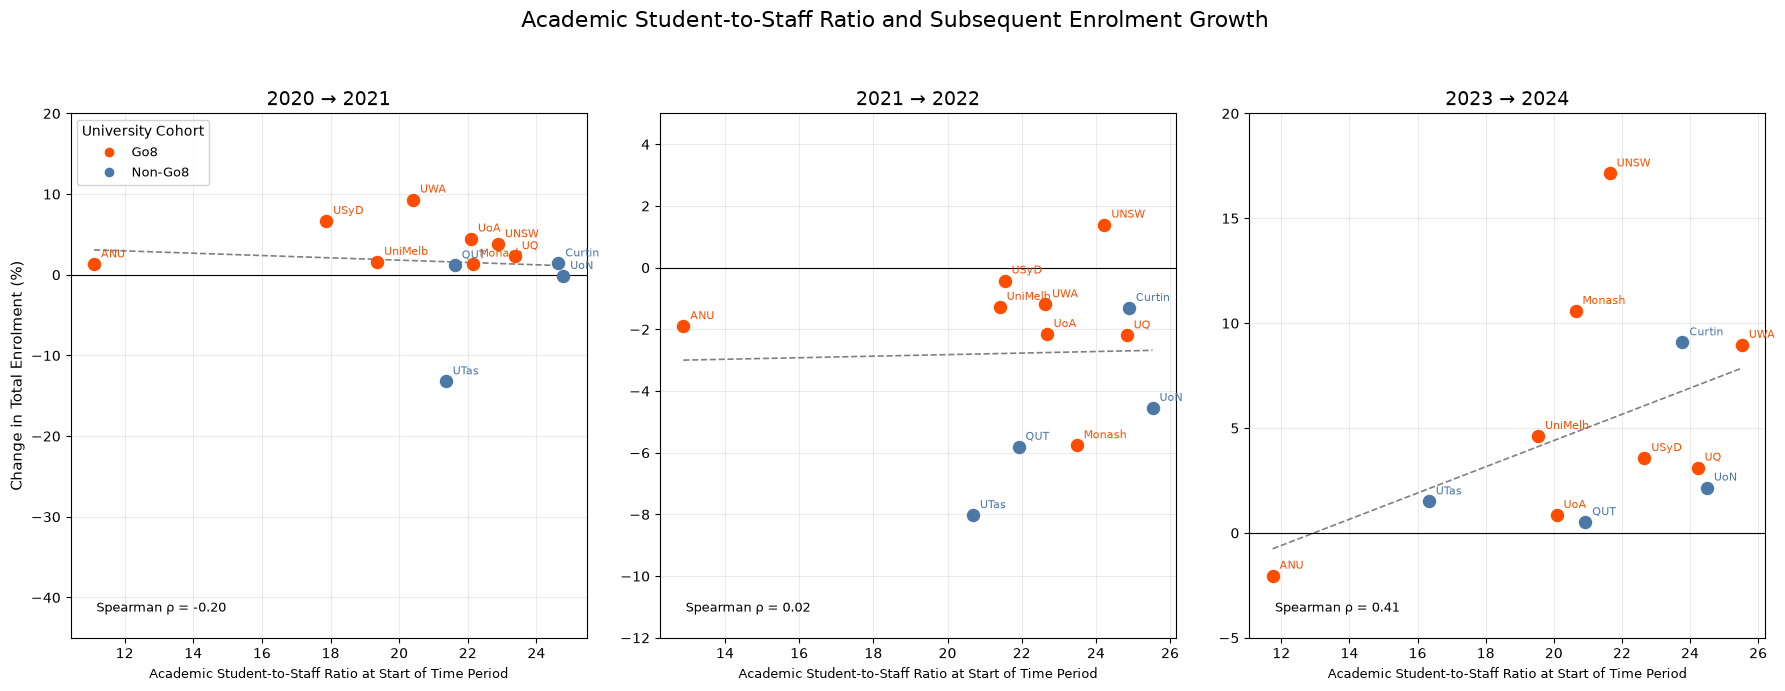

In [85]:
# MAKE GRAPH 4

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from matplotlib.lines import Line2D


# Go8 naming classification

go8 = {
    "The University of Melbourne",
    "Monash University",
    "University of New South Wales",
    "The University of Sydney",
    "The University of Queensland",
    "The Australian National University",
    "The University of Western Australia",
    "The University of Adelaide"
}

lag_panel["Group"] = np.where(
    lag_panel["Label"].isin(go8),
    "Go8",
    "Non-Go8"
)


# University names displayed on the graph

display_names = {
    "The University of Melbourne": "UniMelb",
    "Monash University": "Monash",
    "University of New South Wales": "UNSW",
    "The University of Sydney": "USyD",
    "The University of Queensland": "UQ",
    "The Australian National University": "ANU",
    "The University of Western Australia": "UWA",
    "The University of Adelaide": "UoA",
    "University of Newcastle": "UoN",
    "University of Tasmania": "UTas",
    "Curtin University": "Curtin",
    "Queensland University of Technology": "QUT"
}


# Colours for grouping

group_colours = {
    "Go8": "#FF4D00",
    "Non-Go8": "#4C78A8"
}


# Create three graphs

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 7)
)


periods = [
    "2020 → 2021",
    "2021 → 2022",
    "2023 → 2024"
]


# Plot each period

for ax, period in zip(axes, periods):

    data = lag_panel[
        lag_panel["Period"] == period
    ].copy()


    # Plot Go8 and Non-Go8

    for group in ["Go8", "Non-Go8"]:

        group_data = data[
            data["Group"] == group
        ]

        ax.scatter(
            group_data["Ratio_start"],
            group_data["Enrolment_growth"],
            s=75,
            color=group_colours[group],
            zorder=3
        )


    # University labels

    for _, row in data.iterrows():

        label = display_names.get(
            row["Label"],
            row["Label"]
        )

        ax.annotate(
            label,
            (
                row["Ratio_start"],
                row["Enrolment_growth"]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
            color=group_colours[row["Group"]]
        )


    # Overall trend line

    x = data["Ratio_start"]
    y = data["Enrolment_growth"]

    slope, intercept = np.polyfit(x, y, 1)

    x_line = np.linspace(
        x.min(),
        x.max(),
        100
    )

    ax.plot(
        x_line,
        intercept + slope * x_line,
        linestyle="--",
        linewidth=1.2,
        color="grey",
        zorder=2
    )


    # Zero-growth reference line

    ax.axhline(
        0,
        linewidth=0.8,
        color="black"
    )


    # Spearman correlation

    rho, p = spearmanr(x, y)

    ax.text(
        0.05,
        0.05,
        f"Spearman ρ = {rho:.2f}",
        transform=ax.transAxes,
        fontsize=9
    )


    # Individual graph title

    ax.set_title(
        period,
        fontsize=14
    )


    # X-axis

    ax.set_xlabel(
        "Academic Student-to-Staff Ratio at Start of Time Period",
        fontsize=9
    )


    ax.grid(
        alpha=0.25
    )


# Y-axis label

axes[0].set_ylabel(
    "Change in Total Enrolment (%)",
    fontsize=11
)


# Y-axis ranges

axes[0].set_ylim(-45, 20)
axes[1].set_ylim(-12, 5)
axes[2].set_ylim(-5, 20)


# Legend ONLY inside first graph

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Go8",
        markerfacecolor=group_colours["Go8"],
        markersize=8
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label="Non-Go8",
        markerfacecolor=group_colours["Non-Go8"],
        markersize=8
    )
]


axes[0].legend(
    handles=legend_elements,
    loc="upper left",
    frameon=True,
    framealpha=0.9,
    fontsize=9,
    title="University Cohort"
)


# One overall title for all three graphs

fig.suptitle(
    "Academic Student-to-Staff Ratio and Subsequent Enrolment Growth",
    fontsize=16,
    y=0.98
)


plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)


# Save figure

plt.savefig(
    "ratio_vs_subsequent_enrolment_growth_by_period.png",
    dpi=300,
    bbox_inches="tight"
)


# Show figure

plt.show()

In [86]:
#check the p-values 
from scipy.stats import spearmanr

periods = [
    "2020 → 2021",
    "2021 → 2022",
    "2023 → 2024"
]

for period in periods:

    data = lag_panel[
        lag_panel["Period"] == period
    ].copy()

    rho, p = spearmanr(
        data["Ratio_start"],
        data["Enrolment_growth"]
    )

    print(f"{period}")
    print(f"Spearman ρ = {rho:.4f}")
    print(f"p-value = {p:.4f}")
    print("-" * 30)

2020 → 2021
Spearman ρ = -0.1958
p-value = 0.5419
------------------------------
2021 → 2022
Spearman ρ = 0.0210
p-value = 0.9484
------------------------------
2023 → 2024
Spearman ρ = 0.4056
p-value = 0.1908
------------------------------


In [87]:
# Create cross-sectional RSP and staff-ratio dataset
# Keep 2017–2024 and exclude 2021 because of the one-off RSP funding spike

xs = (
    rsp[
        rsp["Year"].between(2017, 2024)
        & (rsp["Year"] != 2021)
    ]
    .merge(
        staff_clean[
            ["Institution_Code", "Institution",
             "Academic_2017", "Academic_2018",
             "Academic_2019", "Academic_2020",
             "Academic_2021", "Academic_2022",
             "Academic_2023", "Academic_2024"]
        ],
        left_on="HEP Code",
        right_on="Institution_Code",
        how="inner"
    )
)

#calculate each university's share of national RSP funding
xs["RSP_share_pct"] = (
    xs["Amount"]
    / xs.groupby("Year")["Amount"].transform("sum")
    * 100
)

#calculate median values for each university
xs = (
    xs.groupby(
        ["HEP Code", "HEP Name", "Cohort"],
        as_index=False
    )
    .agg(
        Median_share=("RSP_share_pct", "median"),
        Median_ratio=("Academic_2017", "median")
    )
)

print(xs.head())
print("Number of universities:", len(xs))

  HEP Code                             HEP Name       Cohort  Median_share  \
0     1019                James Cook University          IRU      1.256646   
1     1034                   Murdoch University          IRU      0.804623   
2     1055  The University of Western Australia          Go8      4.645169   
3     1058             University of Wollongong  non-aligned      1.537361   
4     2154      Federation University Australia          RUN      0.159450   

   Median_ratio  
0     19.667817  
1     16.645425  
2     20.328683  
3     22.839399  
4     17.965989  
Number of universities: 43


In [88]:
# Create cross-sectional RSP and staff-ratio dataset
# RSP data: 2017–2024, excluding 2021 spike
rsp_xs = rsp[
    rsp["Year"].between(2017, 2024)
    & (rsp["Year"] != 2021)
].copy()

#calculate each university's share of national RSP funding
rsp_xs["RSP_share_pct"] = (
    rsp_xs["Amount"]
    / rsp_xs.groupby("Year")["Amount"].transform("sum")
    * 100
)

#median RSP share for each university
rsp_median = (
    rsp_xs
    .groupby(
        ["HEP Code", "HEP Name", "Cohort"],
        as_index=False
    )["RSP_share_pct"]
    .median()
    .rename(columns={"RSP_share_pct": "Median_share"})
)

# Reshape academic staff ratios

academic_columns = [
    "Academic_2017",
    "Academic_2018",
    "Academic_2019",
    "Academic_2020",
    "Academic_2021",
    "Academic_2022",
    "Academic_2023",
    "Academic_2024"
]

staff_xs = staff_clean[
    ["Institution_Code", "Institution"] + academic_columns
].copy()

staff_long_xs = staff_xs.melt(
    id_vars=["Institution_Code", "Institution"],
    value_vars=academic_columns,
    var_name="Year",
    value_name="Academic_Ratio"
)

staff_long_xs["Year"] = (
    staff_long_xs["Year"]
    .str.replace("Academic_", "")
    .astype(int)
)

#exclude 2021 to match RSP analysis
staff_long_xs = staff_long_xs[
    staff_long_xs["Year"] != 2021
].copy()

#median academic ratio for each university
staff_median = (
    staff_long_xs
    .groupby(
        ["Institution_Code", "Institution"],
        as_index=False
    )["Academic_Ratio"]
    .median()
    .rename(columns={
        "Institution_Code": "HEP Code",
        "Institution": "HEP Name",
        "Academic_Ratio": "Median_ratio"
    })
)
# Combine RSP share and staff ratio

xs = rsp_median.merge(
    staff_median[
        ["HEP Code", "Median_ratio"]
    ],
    on="HEP Code",
    how="inner"
)

print(xs.head())
print("Number of universities:", len(xs))

  HEP Code                             HEP Name       Cohort  Median_share  \
0     1019                James Cook University          IRU      1.256646   
1     1034                   Murdoch University          IRU      0.804623   
2     1055  The University of Western Australia          Go8      4.645169   
3     1058             University of Wollongong  non-aligned      1.537361   
4     2154      Federation University Australia          RUN      0.159450   

   Median_ratio  
0     18.540402  
1     18.407763  
2     20.405833  
3     21.974153  
4     19.815943  
Number of universities: 43


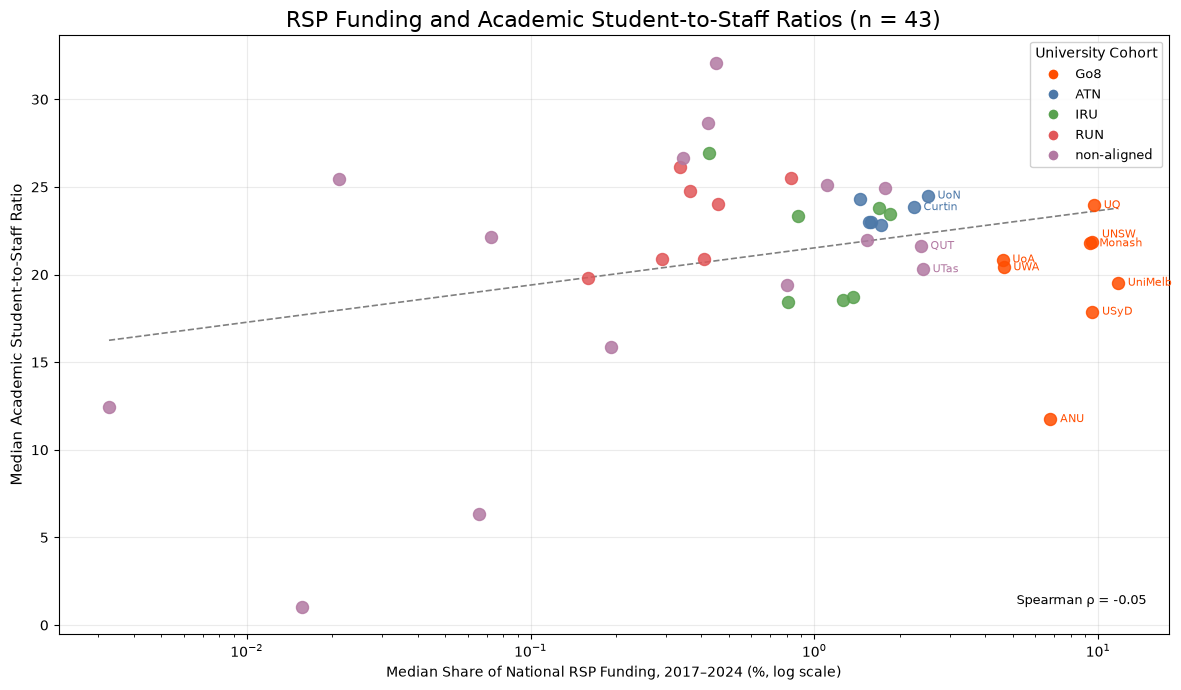

In [89]:
#GRAPH 3
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import spearmanr

# Cohort colours

cohort_colours = {
    "Go8": "#FF4D00",
    "ATN": "#4C78A8",
    "IRU": "#59A14F",
    "RUN": "#E15759",
    "non-aligned": "#B279A2"
}

#university display names

display_names = {
    "The University of Melbourne": "UniMelb",
    "Melbourne": "UniMelb",
    "Monash University": "Monash",
    "Monash": "Monash",
    "University of New South Wales": "UNSW",
    "UNSW": "UNSW",
    "The University of Sydney": "USyD",
    "Sydney": "USyD",
    "The University of Queensland": "UQ",
    "UQ": "UQ",
    "The Australian National University": "ANU",
    "ANU": "ANU",
    "The University of Western Australia": "UWA",
    "UWA": "UWA",
    "The University of Adelaide": "UoA",
    "University of Newcastle": "UoN",
    "The University of Newcastle": "UoN",
    "University of Tasmania": "UTas",
    "Tasmania": "UTas",
    "Curtin University": "Curtin",
    "Curtin": "Curtin",
    "Queensland University of Technology": "QUT",
    "QUT": "QUT"
}

#create graph

fig, ax = plt.subplots(figsize=(12, 7))

#plot each cohort

for cohort in cohort_colours:

    data = xs[xs["Cohort"] == cohort]

    if len(data) == 0:
        continue

    ax.scatter(
        data["Median_share"],
        data["Median_ratio"],
        s=75,
        color=cohort_colours[cohort],
        label=cohort,
        alpha=0.85,
        zorder=3
    )

#label top 12 universities

to_label = xs[
    xs["HEP Name"].isin(top_12_unis)
].copy()

for _, row in to_label.iterrows():

    name = row["HEP Name"]
    label = display_names.get(name, name)

    #move UNSW label slightly higher

    if label == "UNSW":
        offset = (7, 5)
    else:
        offset = (7, 0)

    ax.annotate(
        label,
        (
            row["Median_share"],
            row["Median_ratio"]
        ),
        xytext=offset,
        textcoords="offset points",
        fontsize=8,
        color=cohort_colours.get(
            row["Cohort"],
            "grey"
        ),
        va="center"
    )

#trend line

x = xs["Median_share"]
y = xs["Median_ratio"]

log_x = np.log10(x)

slope, intercept = np.polyfit(
    log_x,
    y,
    1
)

x_line = np.linspace(
    x.min(),
    x.max(),
    100
)

ax.plot(
    x_line,
    intercept + slope * np.log10(x_line),
    linestyle="--",
    linewidth=1.2,
    color="grey",
    zorder=2
)

#spearman correlation

rho, _ = spearmanr(x, y)

ax.text(
    0.98,
    0.05,
    f"Spearman ρ = {rho:.2f}",
    transform=ax.transAxes,
    ha="right",
    fontsize=9
)

#formatting

ax.set_xscale("log")

ax.set_xlabel(
    "Median Share of National RSP Funding, 2017–2024 (%, log scale)",
    fontsize=10
)

ax.set_ylabel(
    "Median Academic Student-to-Staff Ratio",
    fontsize=11
)

ax.set_title(
    f"RSP Funding and Academic Student-to-Staff Ratios (n = {len(xs)})",
    fontsize=16
)

ax.grid(alpha=0.25)

#cohort legend

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=cohort,
        markerfacecolor=colour,
        markersize=8
    )
    for cohort, colour in cohort_colours.items()
    if cohort in xs["Cohort"].unique()
]

ax.legend(
    handles=legend_elements,
    title="University Cohort",
    loc="upper right",
    frameon=True,
    framealpha=0.9,
    fontsize=9
)

#save figure 3

plt.tight_layout()

plt.savefig(
    "RSP_share_vs_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

#show figure 3

plt.show()